# Employee Attrition Prediction with XGBoost

This notebook is the **single submission notebook** for the group project.

## Objective
- Predict employee attrition risk (`Attrition=1`) using **XGBoost**.
- Optimize model performance using **F1-score for Attrition=1** as the primary metric.
- Report accuracy as a secondary metric.

## Data sources (pre-processed split files)
- `outputs/preprocessed_data.csv`
- `outputs/X_train_smote.csv`
- `outputs/X_test.csv`
- `outputs/y_train_smote.csv`
- `outputs/y_test.csv`


## 0) Setup and reproducibility
Install dependencies in this notebook environment (first executable cell), then import libraries and set constants.


In [1]:
%pip install pandas numpy scikit-learn xgboost matplotlib seaborn joblib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 4.0 MB/s  0:00:00 eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import json
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)
from xgboost import XGBClassifier

RANDOM_STATE = 42
PRIMARY_METRIC = "f1"

warnings.filterwarnings("ignore")
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")

print("Environment ready. RANDOM_STATE =", RANDOM_STATE)


Matplotlib is building the font cache; this may take a moment.


Environment ready. RANDOM_STATE = 42


## 1) Load datasets and validate the data contract
This section fails fast if required files or expected schema conditions are missing.


In [3]:
def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "outputs").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing both 'data/' and 'outputs/'.")


def ensure_required_files(root: Path, relative_paths: list[str]) -> dict[str, Path]:
    resolved = {}
    missing = []
    for rel in relative_paths:
        path = root / rel
        resolved[rel] = path
        if not path.exists():
            missing.append(str(path))
    if missing:
        raise FileNotFoundError("Missing required files:\n" + "\n".join(missing))
    return resolved


def convert_boolean_like_strings(df: pd.DataFrame) -> tuple[pd.DataFrame, list[str]]:
    converted_columns = []
    out = df.copy()

    for col in out.columns:
        if out[col].dtype == "object":
            lowered = out[col].dropna().astype(str).str.strip().str.lower()
            unique_values = set(lowered.unique())

            if unique_values and unique_values.issubset({"true", "false"}):
                out[col] = out[col].astype(str).str.strip().str.lower().map({"true": 1, "false": 0}).astype("int8")
                converted_columns.append(col)

    return out, converted_columns


PROJECT_ROOT = find_project_root(Path.cwd())
print("Project root:", PROJECT_ROOT)

required_files = [
    "outputs/preprocessed_data.csv",
    "outputs/X_train_smote.csv",
    "outputs/X_test.csv",
    "outputs/y_train_smote.csv",
    "outputs/y_test.csv",
]
resolved_paths = ensure_required_files(PROJECT_ROOT, required_files)

preprocessed_df = pd.read_csv(resolved_paths["outputs/preprocessed_data.csv"])
X_train = pd.read_csv(resolved_paths["outputs/X_train_smote.csv"])
X_test = pd.read_csv(resolved_paths["outputs/X_test.csv"])
y_train_df = pd.read_csv(resolved_paths["outputs/y_train_smote.csv"])
y_test_df = pd.read_csv(resolved_paths["outputs/y_test.csv"])

# Verify target column contract
if list(y_train_df.columns) != ["Attrition"] or list(y_test_df.columns) != ["Attrition"]:
    raise ValueError("Target column must be exactly 'Attrition' in y_train_smote.csv and y_test.csv.")

y_train = y_train_df["Attrition"].astype(int)
y_test = y_test_df["Attrition"].astype(int)

# Verify feature schema and expected feature count
if list(X_train.columns) != list(X_test.columns):
    missing_in_test = sorted(set(X_train.columns) - set(X_test.columns))
    missing_in_train = sorted(set(X_test.columns) - set(X_train.columns))
    raise ValueError(
        "X_train_smote and X_test columns do not match. \\n"
        f"Missing in test: {missing_in_test} \\n"
        f"Missing in train: {missing_in_train}"
    )

if X_train.shape[1] != 44:
    raise ValueError(f"Expected 44 features, found {X_train.shape[1]}.")

# Check leakage
leak_columns = [col for col in X_train.columns if "attrition" in col.lower()]
if leak_columns:
    raise ValueError(f"Potential target leakage columns found in X: {leak_columns}")

# Convert True/False string columns to numeric 1/0
X_train, converted_train_cols = convert_boolean_like_strings(X_train)
X_test, converted_test_cols = convert_boolean_like_strings(X_test)

# Ensure all columns are numeric after conversion
for col in X_train.columns:
    if X_train[col].dtype == "object" or X_test[col].dtype == "object":
        X_train[col] = pd.to_numeric(X_train[col], errors="raise")
        X_test[col] = pd.to_numeric(X_test[col], errors="raise")

# Final class contract
if set(y_train.unique()) - {0, 1} or set(y_test.unique()) - {0, 1}:
    raise ValueError("Target values must be binary (0/1).")

print("Loaded shapes:")
print("- preprocessed_df:", preprocessed_df.shape)
print("- X_train:", X_train.shape, "| y_train:", y_train.shape)
print("- X_test :", X_test.shape, "| y_test :", y_test.shape)
print("Converted boolean-like columns to numeric:", sorted(set(converted_train_cols + converted_test_cols)))


Project root: /Users/dilandilaruksha/Project/employee-attrition-prediction
Loaded shapes:
- preprocessed_df: (1470, 31)
- X_train: (1972, 44) | y_train: (1972,)
- X_test : (294, 44) | y_test : (294,)
Converted boolean-like columns to numeric: []


## 2) Dataset analysis
Explore preprocessed data, feature characteristics, and class distribution differences between train and test.


In [4]:
# Full dataset overview
print("Preprocessed dataset shape:", preprocessed_df.shape)
print("\nTarget distribution in full preprocessed dataset:")
print(preprocessed_df["Attrition"].value_counts(dropna=False).sort_index())
print("\nTarget percentages:")
print((preprocessed_df["Attrition"].value_counts(normalize=True).sort_index() * 100).round(2).astype(str) + "%")

missing_count = int(preprocessed_df.isna().sum().sum())
duplicate_count = int(preprocessed_df.duplicated().sum())
print("\nMissing values (total):", missing_count)
print("Duplicate rows:", duplicate_count)


Preprocessed dataset shape: (1470, 31)

Target distribution in full preprocessed dataset:
Attrition
0    1233
1     237
Name: count, dtype: int64

Target percentages:
Attrition
0    83.88%
1    16.12%
Name: proportion, dtype: str

Missing values (total): 0
Duplicate rows: 0


In [5]:
# Feature-level summaries
feature_summary = pd.DataFrame({
    "dtype": X_train.dtypes.astype(str),
    "missing_train": X_train.isna().sum(),
    "missing_test": X_test.isna().sum(),
    "nunique_train": X_train.nunique(),
}).sort_values(["dtype", "nunique_train"], ascending=[True, False])

display(feature_summary.head(20))

numeric_summary = X_train.describe().T
numeric_summary = numeric_summary[["mean", "std", "min", "25%", "50%", "75%", "max"]]
print("Numeric summary (first 15 features):")
display(numeric_summary.head(15))

# Dummy prevalence for binary columns
binary_cols = [c for c in X_train.columns if set(X_train[c].dropna().unique()).issubset({0, 1})]
if binary_cols:
    dummy_prevalence = (X_train[binary_cols].mean().sort_values(ascending=False) * 100).round(2)
    print("Top 15 binary feature prevalences in training data (% of 1s):")
    display(dummy_prevalence.head(15).to_frame("pct_ones"))
else:
    print("No binary columns identified for dummy prevalence analysis.")


,dtype,missing_train,missing_test,nunique_train
BusinessTravel_Travel_Frequently,bool,0,0,2
BusinessTravel_Travel_Rarely,bool,0,0,2
Department_Research & Development,bool,0,0,2
Department_Sales,bool,0,0,2
EducationField_Life Sciences,bool,0,0,2
EducationField_Marketing,bool,0,0,2
EducationField_Medical,bool,0,0,2
EducationField_Other,bool,0,0,2
EducationField_Technical Degree,bool,0,0,2
Gender_Male,bool,0,0,2


Numeric summary (first 15 features):


,mean,std,min,25%,50%,75%,max
Age,35.021298,8.989737,18.0,29.00,34.0,40.00,60.0
DailyRate,777.219067,381.808357,103.0,463.00,747.5,1102.25,1499.0
DistanceFromHome,9.549189,7.569272,1.0,3.00,8.0,14.00,29.0
Education,2.737323,0.973503,1.0,2.00,3.0,3.00,5.0
EnvironmentSatisfaction,2.467546,1.063895,1.0,2.00,3.0,3.00,4.0
HourlyRate,65.000507,18.866389,30.0,49.00,64.0,80.25,100.0
JobInvolvement,2.528398,0.742768,1.0,2.00,3.0,3.00,4.0
JobLevel,1.833671,1.023182,1.0,1.00,2.0,2.00,5.0
JobSatisfaction,2.450304,1.075093,1.0,1.00,3.0,3.00,4.0
MonthlyIncome,5766.592799,4281.299409,1009.0,2597.75,4296.0,7254.00,19973.0


Top 15 binary feature prevalences in training data (% of 1s):


,pct_ones
BusinessTravel_Travel_Rarely,59.53
Department_Research & Development,51.72
Gender_Male,51.52
MaritalStatus_Married,31.34
EducationField_Life Sciences,30.93
MaritalStatus_Single,29.01
OverTime_Yes,26.77
Department_Sales,25.10
EducationField_Medical,21.10
JobRole_Sales Executive,19.22


,train_smote_count,test_count,train_smote_pct,test_pct
Class 0,986,247,50.0,84.01
Class 1,986,47,50.0,15.99


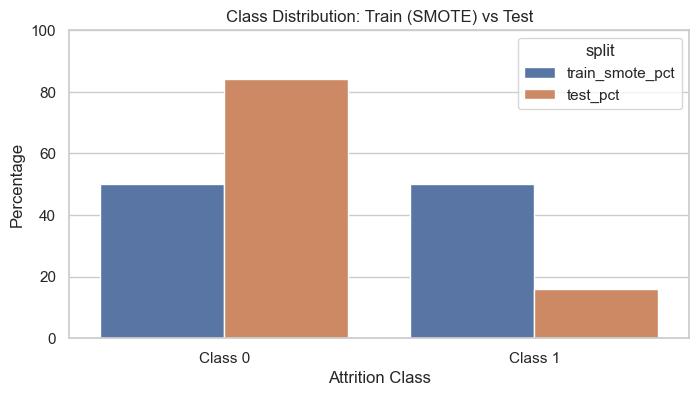

In [6]:
# Train/test class distribution comparison
class_dist = pd.DataFrame({
    "train_smote_count": y_train.value_counts().sort_index(),
    "test_count": y_test.value_counts().sort_index(),
})
class_dist.index = [f"Class {idx}" for idx in class_dist.index]
class_dist["train_smote_pct"] = (class_dist["train_smote_count"] / class_dist["train_smote_count"].sum() * 100).round(2)
class_dist["test_pct"] = (class_dist["test_count"] / class_dist["test_count"].sum() * 100).round(2)

display(class_dist)

plot_df = class_dist[["train_smote_pct", "test_pct"]].reset_index().melt(id_vars="index", var_name="split", value_name="percent")
plt.figure(figsize=(8, 4))
sns.barplot(data=plot_df, x="index", y="percent", hue="split")
plt.title("Class Distribution: Train (SMOTE) vs Test")
plt.xlabel("Attrition Class")
plt.ylabel("Percentage")
plt.ylim(0, 100)
plt.show()


## 3) Baseline XGBoost
Train a baseline model first, then evaluate on test data with threshold = 0.50.


Baseline metrics at threshold 0.50:
threshold    0.5000
f1           0.4167
precision    0.6000
recall       0.3191
accuracy     0.8571
roc_auc      0.7367
dtype: float64


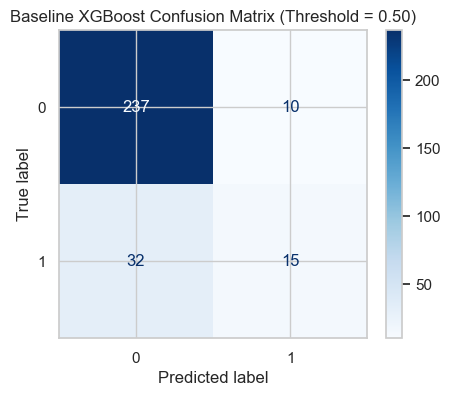

Baseline classification report:
              precision    recall  f1-score   support

           0     0.8810    0.9595    0.9186       247
           1     0.6000    0.3191    0.4167        47

    accuracy                         0.8571       294
   macro avg     0.7405    0.6393    0.6676       294
weighted avg     0.8361    0.8571    0.8384       294



In [7]:
def evaluate_from_probabilities(y_true: pd.Series, y_prob: np.ndarray, threshold: float) -> tuple[dict, np.ndarray]:
    y_pred = (y_prob >= threshold).astype(int)
    metrics = {
        "threshold": float(threshold),
        "f1": float(f1_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "roc_auc": float(roc_auc_score(y_true, y_prob)),
    }
    return metrics, y_pred


baseline_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist",
)

baseline_model.fit(X_train, y_train)
baseline_prob_test = baseline_model.predict_proba(X_test)[:, 1]
baseline_metrics_05, baseline_pred_05 = evaluate_from_probabilities(y_test, baseline_prob_test, threshold=0.50)

print("Baseline metrics at threshold 0.50:")
print(pd.Series(baseline_metrics_05).round(4))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, baseline_pred_05, ax=ax, cmap="Blues")
ax.set_title("Baseline XGBoost Confusion Matrix (Threshold = 0.50)")
plt.show()

print("Baseline classification report:")
print(classification_report(y_test, baseline_pred_05, digits=4))


## 4) Heavy hyperparameter tuning (two stages)
- Stage 1: broad randomized search (`n_iter=200`, `cv=5`, `scoring='f1'`)
- Stage 2: refined randomized search around Stage 1 best params (`n_iter=80`, `cv=5`, `scoring='f1'`)

This section can take significant runtime.


In [8]:
# Split a validation holdout from training data for threshold tuning later
X_tune, X_val, y_tune, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    stratify=y_train,
    random_state=RANDOM_STATE,
)

print("Tuning split shapes:")
print("- X_tune:", X_tune.shape, "| y_tune:", y_tune.shape)
print("- X_val :", X_val.shape, "| y_val :", y_val.shape)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist",
)

param_dist_stage1 = {
    "n_estimators": [200, 300, 400, 500, 700, 900, 1100],
    "max_depth": [3, 4, 5, 6, 7, 8, 10],
    "learning_rate": [0.005, 0.01, 0.02, 0.03, 0.05, 0.08, 0.10, 0.15, 0.20],
    "min_child_weight": [1, 2, 3, 4, 5, 7, 10],
    "subsample": [0.60, 0.70, 0.80, 0.90, 1.00],
    "colsample_bytree": [0.60, 0.70, 0.80, 0.90, 1.00],
    "gamma": [0.0, 0.1, 0.2, 0.3, 0.5, 1.0, 2.0],
    "reg_alpha": [0.0, 0.001, 0.01, 0.1, 0.5, 1.0, 5.0],
    "reg_lambda": [0.5, 1.0, 1.5, 2.0, 3.0, 5.0, 10.0],
}

stage1_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist_stage1,
    n_iter=200,
    scoring=PRIMARY_METRIC,
    n_jobs=-1,
    cv=cv,
    verbose=1,
    random_state=RANDOM_STATE,
    refit=True,
    return_train_score=True,
)

stage1_search.fit(X_tune, y_tune)

print("Stage 1 best CV F1:", round(stage1_search.best_score_, 5))
print("Stage 1 best params:")
print(stage1_search.best_params_)


Tuning split shapes:
- X_tune: (1577, 44) | y_tune: (1577,)
- X_val : (395, 44) | y_val : (395,)
Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Stage 1 best CV F1: 0.92892
Stage 1 best params:
{'subsample': 1.0, 'reg_lambda': 5.0, 'reg_alpha': 0.01, 'n_estimators': 700, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.2, 'gamma': 0.1, 'colsample_bytree': 0.6}


In [9]:
def refine_int(value: int, min_value: int, max_value: int, step: int = 1) -> list[int]:
    raw = [value - 2 * step, value - step, value, value + step, value + 2 * step]
    clipped = [min(max(v, min_value), max_value) for v in raw]
    return sorted(set(int(v) for v in clipped))


def refine_float(value: float, min_value: float, max_value: float, multipliers=(0.70, 0.85, 1.00, 1.15, 1.30), ndigits: int = 4) -> list[float]:
    raw = [value * m for m in multipliers]
    clipped = [min(max(v, min_value), max_value) for v in raw]
    return sorted(set(round(float(v), ndigits) for v in clipped))


stage1_best = stage1_search.best_params_

param_dist_stage2 = {
    "n_estimators": refine_int(stage1_best["n_estimators"], min_value=100, max_value=1500, step=100),
    "max_depth": refine_int(stage1_best["max_depth"], min_value=2, max_value=14, step=1),
    "learning_rate": refine_float(stage1_best["learning_rate"], min_value=0.003, max_value=0.30),
    "min_child_weight": refine_int(stage1_best["min_child_weight"], min_value=1, max_value=20, step=1),
    "subsample": refine_float(stage1_best["subsample"], min_value=0.50, max_value=1.00),
    "colsample_bytree": refine_float(stage1_best["colsample_bytree"], min_value=0.50, max_value=1.00),
    "gamma": sorted(set([0.0] + refine_float(stage1_best["gamma"], min_value=0.0, max_value=5.0))),
    "reg_alpha": sorted(set([0.0] + refine_float(stage1_best["reg_alpha"], min_value=0.0, max_value=10.0))),
    "reg_lambda": refine_float(stage1_best["reg_lambda"], min_value=0.1, max_value=20.0),
}

stage2_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist_stage2,
    n_iter=80,
    scoring=PRIMARY_METRIC,
    n_jobs=-1,
    cv=cv,
    verbose=1,
    random_state=RANDOM_STATE,
    refit=True,
    return_train_score=True,
)

stage2_search.fit(X_tune, y_tune)

print("Stage 2 best CV F1:", round(stage2_search.best_score_, 5))
print("Stage 2 best params:")
print(stage2_search.best_params_)

cv_comparison = pd.DataFrame(
    {
        "search_stage": ["stage_1", "stage_2"],
        "best_cv_f1": [stage1_search.best_score_, stage2_search.best_score_],
    }
)
display(cv_comparison)


Fitting 5 folds for each of 80 candidates, totalling 400 fits
Stage 2 best CV F1: 0.92558
Stage 2 best params:
{'subsample': 1.0, 'reg_lambda': 4.25, 'reg_alpha': 0.007, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.26, 'gamma': 0.07, 'colsample_bytree': 0.5}


,search_stage,best_cv_f1
0,stage_1,0.92892
1,stage_2,0.92558


## 5) Threshold tuning on validation split
Search threshold values from **0.10 to 0.90 (step 0.01)** to maximize F1 for Attrition=1.


Best validation threshold: 0.48
Best validation F1: 0.92268


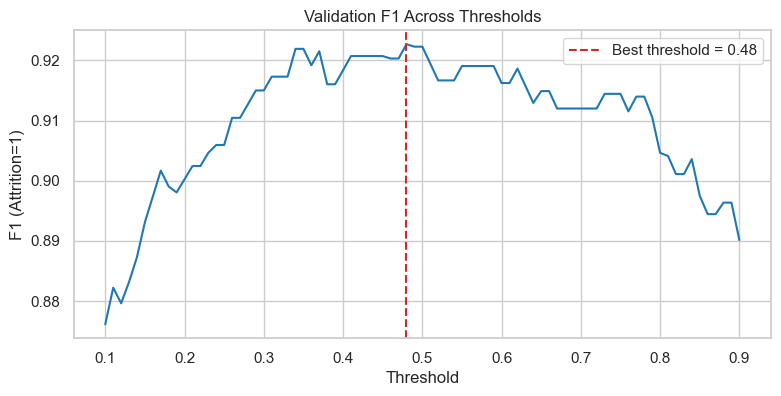

In [10]:
best_params = stage2_search.best_params_

threshold_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist",
    **best_params,
)
threshold_model.fit(X_tune, y_tune)

val_prob = threshold_model.predict_proba(X_val)[:, 1]
thresholds = np.round(np.arange(0.10, 0.91, 0.01), 2)
val_f1_scores = [f1_score(y_val, (val_prob >= t).astype(int)) for t in thresholds]

best_threshold_idx = int(np.argmax(val_f1_scores))
best_threshold = float(thresholds[best_threshold_idx])
best_val_f1 = float(val_f1_scores[best_threshold_idx])

print("Best validation threshold:", best_threshold)
print("Best validation F1:", round(best_val_f1, 5))

plt.figure(figsize=(9, 4))
plt.plot(thresholds, val_f1_scores, color="tab:blue")
plt.axvline(best_threshold, color="tab:red", linestyle="--", label=f"Best threshold = {best_threshold:.2f}")
plt.title("Validation F1 Across Thresholds")
plt.xlabel("Threshold")
plt.ylabel("F1 (Attrition=1)")
plt.legend()
plt.show()


## 6) Final test evaluation
Train final tuned model on full training data and evaluate on test set with:
- fixed threshold (`0.50`)
- selected threshold (best validation threshold)


Final test metrics:


,model,evaluation,threshold,f1,precision,recall,accuracy,roc_auc
0,Baseline XGBoost,threshold=0.50,0.50,0.4167,0.6000,0.3191,0.8571,0.7367
1,Tuned XGBoost,threshold=0.50,0.50,0.4000,0.5357,0.3191,0.8469,0.7659
2,Tuned XGBoost,threshold=0.48,0.48,0.3947,0.5172,0.3191,0.8435,0.7659


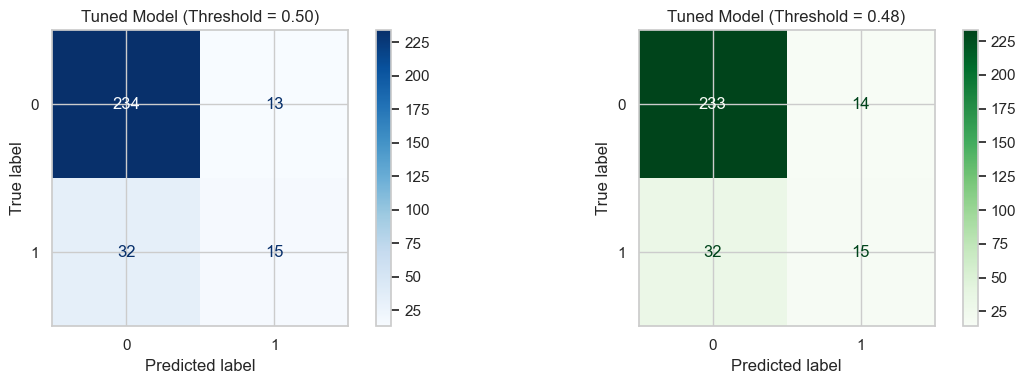

Classification report (Tuned, threshold=0.50):
              precision    recall  f1-score   support

           0     0.8797    0.9474    0.9123       247
           1     0.5357    0.3191    0.4000        47

    accuracy                         0.8469       294
   macro avg     0.7077    0.6333    0.6561       294
weighted avg     0.8247    0.8469    0.8304       294

Classification report (Tuned, threshold=best):
              precision    recall  f1-score   support

           0     0.8792    0.9433    0.9102       247
           1     0.5172    0.3191    0.3947        47

    accuracy                         0.8435       294
   macro avg     0.6982    0.6312    0.6524       294
weighted avg     0.8214    0.8435    0.8278       294



In [11]:
final_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist",
    **best_params,
)
final_model.fit(X_train, y_train)

tuned_prob_test = final_model.predict_proba(X_test)[:, 1]
tuned_metrics_05, tuned_pred_05 = evaluate_from_probabilities(y_test, tuned_prob_test, threshold=0.50)
tuned_metrics_best, tuned_pred_best = evaluate_from_probabilities(y_test, tuned_prob_test, threshold=best_threshold)

metrics_table = pd.DataFrame(
    [
        {"model": "Baseline XGBoost", "evaluation": "threshold=0.50", **baseline_metrics_05},
        {"model": "Tuned XGBoost", "evaluation": "threshold=0.50", **tuned_metrics_05},
        {"model": "Tuned XGBoost", "evaluation": f"threshold={best_threshold:.2f}", **tuned_metrics_best},
    ]
)

print("Final test metrics:")
display(metrics_table.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(y_test, tuned_pred_05, ax=axes[0], cmap="Blues")
axes[0].set_title("Tuned Model (Threshold = 0.50)")

ConfusionMatrixDisplay.from_predictions(y_test, tuned_pred_best, ax=axes[1], cmap="Greens")
axes[1].set_title(f"Tuned Model (Threshold = {best_threshold:.2f})")
plt.tight_layout()
plt.show()

print("Classification report (Tuned, threshold=0.50):")
print(classification_report(y_test, tuned_pred_05, digits=4))

print("Classification report (Tuned, threshold=best):")
print(classification_report(y_test, tuned_pred_best, digits=4))


## 7) Explainability and error analysis
Use XGBoost feature importance (`gain`, `weight`) and inspect false positives/false negatives.


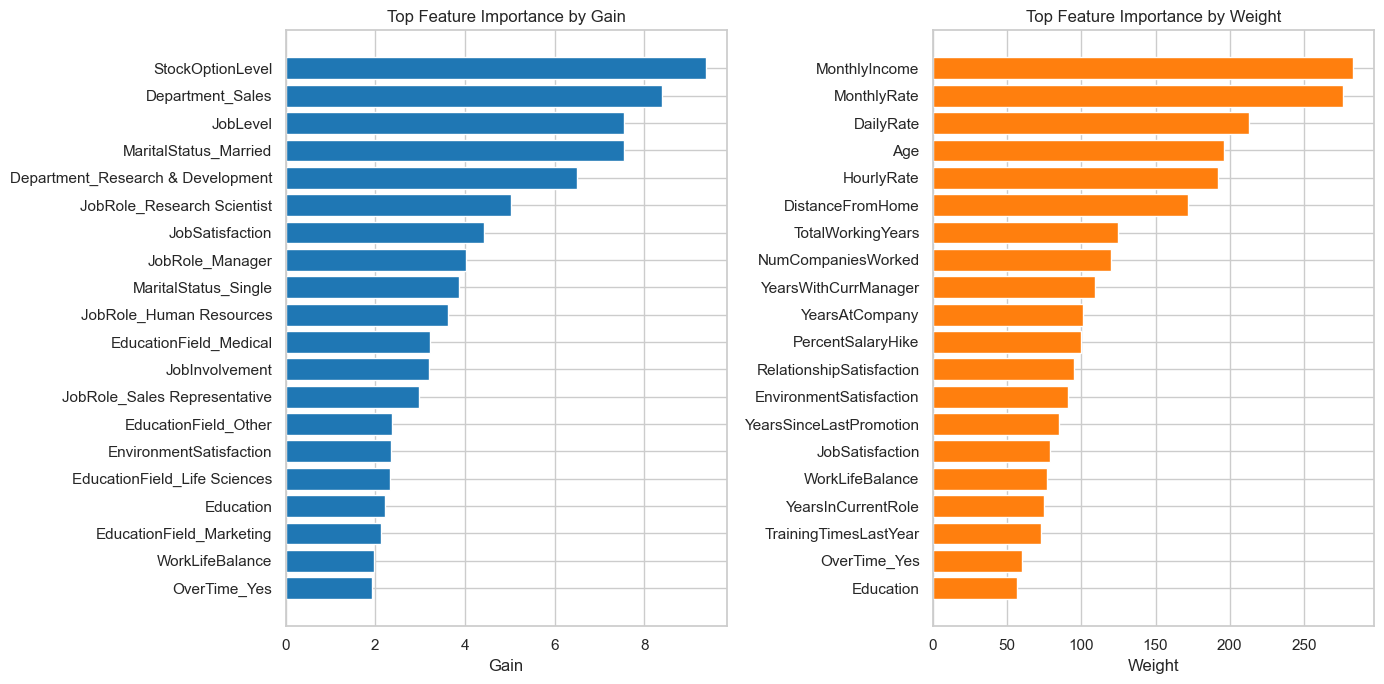

Top 10 features by gain:


,gain
StockOptionLevel,9.366296
Department_Sales,8.388496
JobLevel,7.546221
MaritalStatus_Married,7.536360
Department_Research & Development,6.493773
JobRole_Research Scientist,5.025455
JobSatisfaction,4.427661
JobRole_Manager,4.026235
MaritalStatus_Single,3.862391
JobRole_Human Resources,3.613032


Top 10 features by weight:


,weight
MonthlyIncome,283.0
MonthlyRate,276.0
DailyRate,213.0
Age,196.0
HourlyRate,192.0
DistanceFromHome,172.0
TotalWorkingYears,125.0
NumCompaniesWorked,120.0
YearsWithCurrManager,109.0
YearsAtCompany,101.0


In [12]:
booster = final_model.get_booster()

importance_gain = pd.Series(booster.get_score(importance_type="gain"), name="gain")
importance_weight = pd.Series(booster.get_score(importance_type="weight"), name="weight")

def remap_findex(series: pd.Series, columns: pd.Index) -> pd.Series:
    if series.empty:
        return series
    if series.index.to_series().str.match(r"^f\\d+$").all():
        mapping = {f"f{i}": col for i, col in enumerate(columns)}
        series.index = series.index.map(lambda key: mapping.get(key, key))
    return series

importance_gain = remap_findex(importance_gain, X_train.columns).sort_values(ascending=False)
importance_weight = remap_findex(importance_weight, X_train.columns).sort_values(ascending=False)

top_n = 20
top_gain = importance_gain.head(top_n).sort_values()
top_weight = importance_weight.head(top_n).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
if not top_gain.empty:
    axes[0].barh(top_gain.index, top_gain.values, color="tab:blue")
axes[0].set_title("Top Feature Importance by Gain")
axes[0].set_xlabel("Gain")

if not top_weight.empty:
    axes[1].barh(top_weight.index, top_weight.values, color="tab:orange")
axes[1].set_title("Top Feature Importance by Weight")
axes[1].set_xlabel("Weight")

plt.tight_layout()
plt.show()

print("Top 10 features by gain:")
display(importance_gain.head(10).to_frame())

print("Top 10 features by weight:")
display(importance_weight.head(10).to_frame())


In [13]:
test_results = pd.DataFrame({
    "y_true": y_test.values,
    "y_prob": tuned_prob_test,
    "y_pred_0_50": tuned_pred_05,
    "y_pred_best": tuned_pred_best,
}, index=X_test.index)

conditions = [
    (test_results["y_true"] == 1) & (test_results["y_pred_best"] == 0),
    (test_results["y_true"] == 0) & (test_results["y_pred_best"] == 1),
]
labels = ["False Negative", "False Positive"]

test_results["error_type"] = np.select(conditions, labels, default="Correct")

error_counts = test_results["error_type"].value_counts()
print("Error breakdown (best threshold):")
print(error_counts)

false_negatives = test_results[test_results["error_type"] == "False Negative"].sort_values("y_prob", ascending=False)
false_positives = test_results[test_results["error_type"] == "False Positive"].sort_values("y_prob", ascending=False)

print("\nTop 10 false negatives (closest to threshold):")
display(false_negatives.head(10))

print("Top 10 false positives (highest predicted risk but actually stayed):")
display(false_positives.head(10))

# Feature profile differences for key error classes
X_test_reset = X_test.copy()
X_test_reset["error_type"] = test_results["error_type"].values

if (X_test_reset["error_type"] == "False Negative").any() and ((y_test == 1) & (tuned_pred_best == 1)).any():
    fn_means = X_test_reset[X_test_reset["error_type"] == "False Negative"].drop(columns="error_type").mean()
    tp_means = X_test[(y_test == 1) & (tuned_pred_best == 1)].mean()
    fn_vs_tp_delta = (fn_means - tp_means).abs().sort_values(ascending=False).head(10)
    print("Top 10 absolute feature-mean gaps: False Negatives vs True Positives")
    display(fn_vs_tp_delta.to_frame("abs_mean_gap"))

if (X_test_reset["error_type"] == "False Positive").any() and ((y_test == 0) & (tuned_pred_best == 0)).any():
    fp_means = X_test_reset[X_test_reset["error_type"] == "False Positive"].drop(columns="error_type").mean()
    tn_means = X_test[(y_test == 0) & (tuned_pred_best == 0)].mean()
    fp_vs_tn_delta = (fp_means - tn_means).abs().sort_values(ascending=False).head(10)
    print("Top 10 absolute feature-mean gaps: False Positives vs True Negatives")
    display(fp_vs_tn_delta.to_frame("abs_mean_gap"))


Error breakdown (best threshold):
error_type
Correct           248
False Negative     32
False Positive     14
Name: count, dtype: int64

Top 10 false negatives (closest to threshold):


,y_true,y_prob,y_pred_0_50,y_pred_best,error_type
158,1,0.477451,0,0,False Negative
222,1,0.428611,0,0,False Negative
95,1,0.425780,0,0,False Negative
57,1,0.374960,0,0,False Negative
67,1,0.329468,0,0,False Negative
219,1,0.324801,0,0,False Negative
176,1,0.234626,0,0,False Negative
20,1,0.230862,0,0,False Negative
190,1,0.129307,0,0,False Negative
291,1,0.126742,0,0,False Negative


Top 10 false positives (highest predicted risk but actually stayed):


,y_true,y_prob,y_pred_0_50,y_pred_best,error_type
223,0,0.971988,1,1,False Positive
104,0,0.932448,1,1,False Positive
0,0,0.932050,1,1,False Positive
199,0,0.770683,1,1,False Positive
136,0,0.769696,1,1,False Positive
143,0,0.714584,1,1,False Positive
257,0,0.691435,1,1,False Positive
34,0,0.582799,1,1,False Positive
273,0,0.573522,1,1,False Positive
65,0,0.564815,1,1,False Positive


Top 10 absolute feature-mean gaps: False Negatives vs True Positives


,abs_mean_gap
MonthlyIncome,1787.466667
MonthlyRate,960.483333
TotalWorkingYears,4.895833
Age,4.827083
YearsAtCompany,4.695833
DistanceFromHome,3.933333
HourlyRate,2.579167
YearsWithCurrManager,2.287500
DailyRate,1.968750
YearsSinceLastPromotion,1.745833


Top 10 absolute feature-mean gaps: False Positives vs True Negatives


,abs_mean_gap
MonthlyIncome,3530.192213
MonthlyRate,171.871858
DailyRate,69.349479
Age,5.877376
TotalWorkingYears,5.323728
YearsAtCompany,4.681790
YearsInCurrentRole,3.656652
HourlyRate,3.187308
YearsWithCurrManager,2.721643
PercentSalaryHike,2.190374


## 8) Export optional artifacts
Save final metrics, predictions, and trained model for report and reproducibility.


In [14]:
metrics_dir = PROJECT_ROOT / "outputs" / "metrics"
preds_dir = PROJECT_ROOT / "outputs" / "predictions"
models_dir = PROJECT_ROOT / "outputs" / "models"

for out_dir in [metrics_dir, preds_dir, models_dir]:
    out_dir.mkdir(parents=True, exist_ok=True)

metrics_payload = {
    "baseline_threshold_0_50": baseline_metrics_05,
    "tuned_threshold_0_50": tuned_metrics_05,
    "tuned_threshold_best": tuned_metrics_best,
    "best_threshold": best_threshold,
    "best_params_stage2": best_params,
    "cv_best_score_stage1_f1": float(stage1_search.best_score_),
    "cv_best_score_stage2_f1": float(stage2_search.best_score_),
    "created_utc": pd.Timestamp.utcnow().isoformat(),
}

metrics_path = metrics_dir / "xgboost_metrics.json"
preds_path = preds_dir / "xgboost_test_predictions.csv"
model_path = models_dir / "xgboost_attrition_model.joblib"

with metrics_path.open("w", encoding="utf-8") as f:
    json.dump(metrics_payload, f, indent=2)

predictions_export = pd.DataFrame({
    "index": X_test.index,
    "y_true": y_test.values,
    "y_prob": tuned_prob_test,
    "y_pred_0_50": tuned_pred_05,
    "y_pred_best": tuned_pred_best,
    "error_type_best": test_results["error_type"].values,
})
predictions_export.to_csv(preds_path, index=False)

joblib.dump(final_model, model_path)

print("Saved artifacts:")
print("-", metrics_path)
print("-", preds_path)
print("-", model_path)


Saved artifacts:
- /Users/dilandilaruksha/Project/employee-attrition-prediction/outputs/metrics/xgboost_metrics.json
- /Users/dilandilaruksha/Project/employee-attrition-prediction/outputs/predictions/xgboost_test_predictions.csv
- /Users/dilandilaruksha/Project/employee-attrition-prediction/outputs/models/xgboost_attrition_model.joblib


## 9) Conclusion
Summarize baseline vs tuned results and verify improvement target.


In [15]:
baseline_f1 = baseline_metrics_05["f1"]
tuned_best_f1 = tuned_metrics_best["f1"]
improvement = tuned_best_f1 - baseline_f1

summary = pd.DataFrame(
    {
        "Metric": [
            "Baseline F1 (threshold=0.50)",
            "Tuned F1 (threshold=best)",
            "F1 Improvement",
            "Baseline Accuracy",
            "Tuned Accuracy (best threshold)",
            "Best Threshold",
        ],
        "Value": [
            round(baseline_f1, 4),
            round(tuned_best_f1, 4),
            round(improvement, 4),
            round(baseline_metrics_05["accuracy"], 4),
            round(tuned_metrics_best["accuracy"], 4),
            round(best_threshold, 2),
        ],
    }
)

display(summary)

if improvement >= 0.03:
    print("Quality gate passed: Tuned F1 improved by at least +0.03 over baseline.")
else:
    print("Quality gate not met (+0.03 F1). Keep tuned model with the best recall/F1 tradeoff and discuss in report.")

print("\nPractical HR interpretation:")
print("- Use the probability score as attrition risk for proactive retention planning.")
print("- Prioritize high-risk employees identified by the selected threshold.")
print("- Review false negatives regularly to reduce missed attrition cases.")


,Metric,Value
0,Baseline F1 (threshold=0.50),0.4167
1,Tuned F1 (threshold=best),0.3947
2,F1 Improvement,-0.0219
3,Baseline Accuracy,0.8571
4,Tuned Accuracy (best threshold),0.8435
5,Best Threshold,0.4800


Quality gate not met (+0.03 F1). Keep tuned model with the best recall/F1 tradeoff and discuss in report.

Practical HR interpretation:
- Use the probability score as attrition risk for proactive retention planning.
- Prioritize high-risk employees identified by the selected threshold.
- Review false negatives regularly to reduce missed attrition cases.
